In [1]:
# =====================================================
# CELDA 1 - CONFIGURACIÓN DEL ENTORNO
# =====================================================

import os
import sys
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

# Scikit-learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

# =====================================================
# CONFIGURACIÓN GENERAL
# =====================================================

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Configuración gráfica
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# =====================================================
# VERIFICACIÓN DEL ENTORNO
# =====================================================

print(f"Versión de Python      : {sys.version.split()[0]}")
print(f"Versión de TensorFlow : {tf.__version__}")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"✅ GPU disponible       : {gpus[0].name}")
else:
    print("⚠️ GPU no disponible. Se utilizará CPU.")
    print("En Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU")

print(f"Semilla utilizada      : {RANDOM_SEED}")

Versión de Python      : 3.13.15
Versión de TensorFlow : 2.20.0
⚠️ GPU no disponible. Se utilizará CPU.
En Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU
Semilla utilizada      : 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import zipfile
import os

ruta_drive = '/content/drive/MyDrive/Proyecto_Centrum PUCP/BDatos'  # ajusta al nombre real de tu carpeta
ruta_destino = '/content/dataset'
os.makedirs(ruta_destino, exist_ok=True)

# 1. Leer el CSV directamente desde Drive (no hace falta descomprimir nada)
df = pd.read_csv(os.path.join(ruta_drive, 'Data_Entry_2017.csv'))  # ajusta el nombre
print(df.shape)
df.head()

# 2. Descomprimir los ZIP hacia el disco local de Colab
archivos_zip = ['images_001.zip', 'images_002.zip', 'images_003.zip', 'images_004.zip']  # ajusta nombres

for archivo in archivos_zip:
    with zipfile.ZipFile(os.path.join(ruta_drive, archivo), 'r') as zip_ref:
        zip_ref.extractall(ruta_destino)

(112120, 12)


In [4]:
from glob import glob

image_files = glob('/content/dataset/**/*.png', recursive=True)

print(f"Total de imágenes PNG encontradas: {len(image_files):,}")

Total de imágenes PNG encontradas: 34,999


In [5]:
# =====================================================
# CELDA 3 - MAPEO DE IMÁGENES Y ENCODING MULTILABEL
# =====================================================

import os
from glob import glob
from itertools import chain
import numpy as np
import pandas as pd

# -----------------------------------------------------
# 1. Verificar DataFrame cargado
# -----------------------------------------------------

print(f"Total de registros en el CSV original: {len(df):,}")

# -----------------------------------------------------
# 2. Mapear todas las imágenes PNG extraídas
# -----------------------------------------------------

image_paths = {
    os.path.basename(path): path
    for path in glob(
        os.path.join(ruta_destino, "**", "*.png"),
        recursive=True
    )
}

print(f"Imágenes físicas encontradas: {len(image_paths):,}")

# -----------------------------------------------------
# 3. Asociar cada Image Index con su ruta física
# -----------------------------------------------------

df["path"] = df["Image Index"].map(image_paths.get)

# Mantener únicamente registros cuya imagen existe
df = df.dropna(subset=["path"]).reset_index(drop=True)

print(f"Registros disponibles para entrenamiento: {len(df):,}")

# -----------------------------------------------------
# 4. Eliminar 'No Finding' como clase independiente
# -----------------------------------------------------

df["Finding Labels"] = df["Finding Labels"].map(
    lambda x: x.replace("No Finding", "")
)

# -----------------------------------------------------
# 5. Obtener lista única de patologías
# -----------------------------------------------------

all_labels = np.unique(
    list(
        chain(
            *df["Finding Labels"]
            .map(lambda x: x.split("|"))
            .tolist()
        )
    )
)

# Eliminar cadenas vacías creadas por 'No Finding'
all_labels = [label for label in all_labels if label != ""]

# -----------------------------------------------------
# 6. Crear columnas binarias multilabel
# -----------------------------------------------------

for label in all_labels:

    # MEJORA:
    # Se compara contra etiquetas separadas exactamente,
    # en lugar de buscar si el texto aparece parcialmente.
    df[label] = df["Finding Labels"].map(
        lambda finding: 1.0
        if label in finding.split("|")
        else 0.0
    )

# -----------------------------------------------------
# 7. Verificaciones finales
# -----------------------------------------------------

print(f"\nTotal de patologías detectadas: {len(all_labels)}")
print(all_labels)

print(
    f"\nNúmero de imágenes sin hallazgos: "
    f"{(df['Finding Labels'] == '').sum():,}"
)

# Debemos obtener exactamente 14 patologías
if len(all_labels) != 14:
    print(
        "\n⚠️ ADVERTENCIA: se esperaban 14 patologías."
        " Revisa las etiquetas detectadas."
    )
else:
    print("\n✅ Se detectaron correctamente las 14 patologías.")

# Mostrar una muestra
display(
    df[
        ["Image Index", "path", "Finding Labels"] + all_labels[:5]
    ].head()
)

Total de registros en el CSV original: 112,120
Imágenes físicas encontradas: 34,999
Registros disponibles para entrenamiento: 34,999

Total de patologías detectadas: 14
[np.str_('Atelectasis'), np.str_('Cardiomegaly'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Effusion'), np.str_('Emphysema'), np.str_('Fibrosis'), np.str_('Hernia'), np.str_('Infiltration'), np.str_('Mass'), np.str_('Nodule'), np.str_('Pleural_Thickening'), np.str_('Pneumonia'), np.str_('Pneumothorax')]

Número de imágenes sin hallazgos: 20,353

✅ Se detectaron correctamente las 14 patologías.


,Image Index,path,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion
0,00000001_000.png,/content/dataset/images/00000001_000.png,Cardiomegaly,0.0,1.0,0.0,0.0,0.0
1,00000001_001.png,/content/dataset/images/00000001_001.png,Cardiomegaly|Emphysema,0.0,1.0,0.0,0.0,0.0
2,00000001_002.png,/content/dataset/images/00000001_002.png,Cardiomegaly|Effusion,0.0,1.0,0.0,0.0,1.0
3,00000002_000.png,/content/dataset/images/00000002_000.png,,0.0,0.0,0.0,0.0,0.0
4,00000003_000.png,/content/dataset/images/00000003_000.png,Hernia,0.0,0.0,0.0,0.0,0.0


Total de imágenes en el subconjunto: 34,999
Total sin hallazgos ('No Finding'): 20,353 (58.15%)

Frecuencia por patología:


,Patología,Casos,Porcentaje (%)
0,Infiltration,5048,14.42
1,Effusion,3370,9.63
2,Atelectasis,3345,9.56
3,Nodule,1803,5.15
4,Pneumothorax,1406,4.02
5,Mass,1332,3.81
6,Consolidation,1241,3.55
7,Pleural_Thickening,1018,2.91
8,Cardiomegaly,994,2.84
9,Emphysema,726,2.07


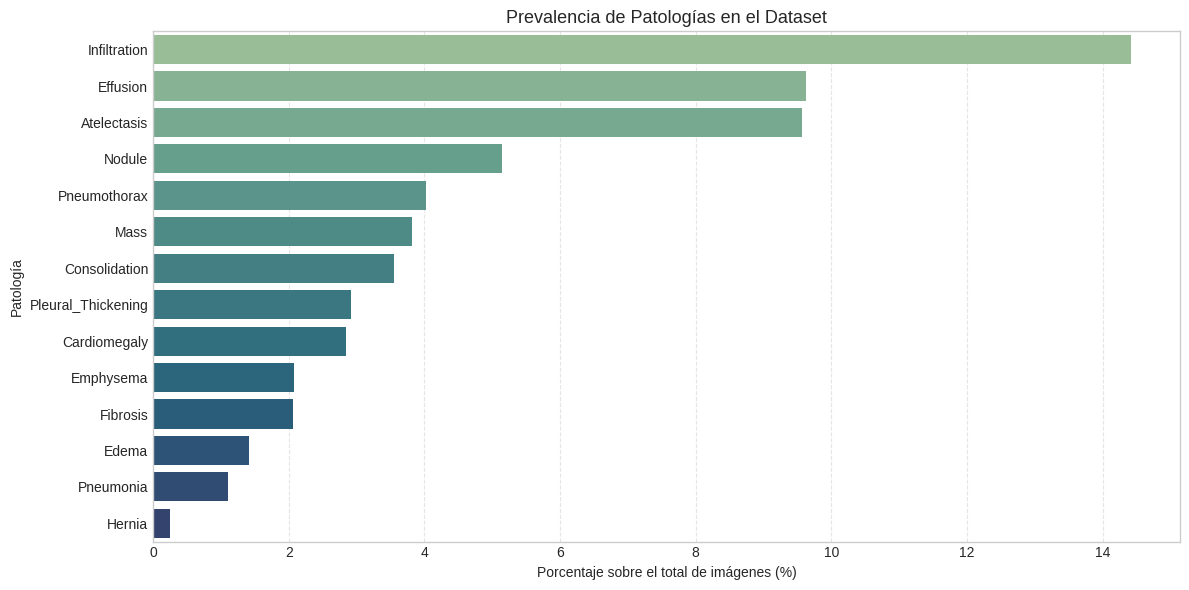

In [6]:
# =====================================================
# CELDA 4 - EDA: FRECUENCIA DE PATOLOGÍAS
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------------------------------
# 1. Calcular frecuencia de cada patología
# -----------------------------------------------------

disease_counts = (
    df[all_labels]
    .sum()
    .sort_values(ascending=False)
)

total_images = len(df)

# Las imágenes "No Finding" quedaron como cadena vacía
no_finding_count = (df["Finding Labels"] == "").sum()

print(f"Total de imágenes en el subconjunto: {total_images:,}")

print(
    f"Total sin hallazgos ('No Finding'): "
    f"{no_finding_count:,} "
    f"({no_finding_count / total_images * 100:.2f}%)"
)

# -----------------------------------------------------
# 2. Crear tabla resumen
# -----------------------------------------------------

df_disease_freq = pd.DataFrame({
    "Patología": disease_counts.index,
    "Casos": disease_counts.astype(int).values,
    "Porcentaje (%)": (
        disease_counts.values / total_images * 100
    ).round(2)
})

print("\nFrecuencia por patología:")
display(df_disease_freq)

# -----------------------------------------------------
# 3. Gráfico de prevalencia
# -----------------------------------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_disease_freq,
    x="Porcentaje (%)",
    y="Patología",
    hue="Patología",
    palette="crest",
    legend=False
)

plt.title(
    "Prevalencia de Patologías en el Dataset",
    fontsize=13
)

plt.xlabel(
    "Porcentaje sobre el total de imágenes (%)"
)

plt.ylabel("Patología")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# MEJORA:
# Se mantiene el mismo EDA del experimento DenseNet121
# para garantizar comparabilidad entre ambos modelos.
#
# Los porcentajes NO tienen por qué sumar 100%, porque
# una radiografía puede presentar varias patologías.
# -----------------------------------------------------

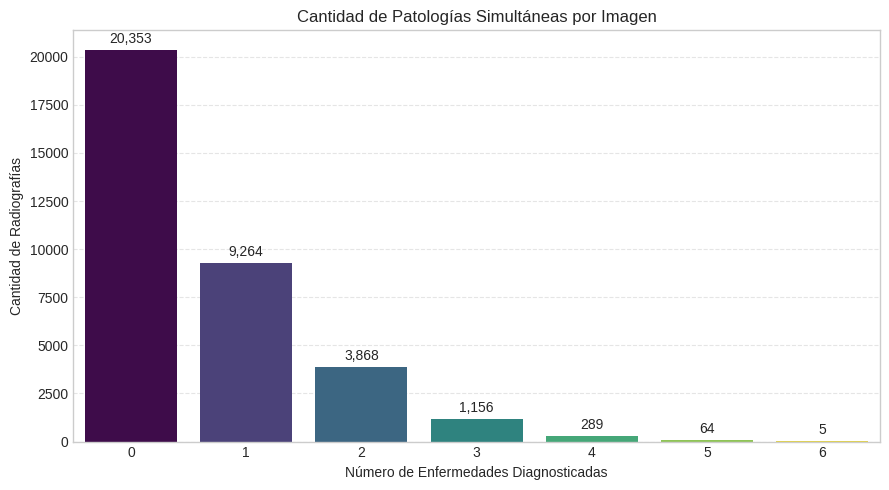

,Número de patologías,Cantidad de radiografías,Porcentaje (%)
0,0,20353,58.15
1,1,9264,26.47
2,2,3868,11.05
3,3,1156,3.30
4,4,289,0.83
5,5,64,0.18
6,6,5,0.01


In [7]:
# =====================================================
# CELDA 5 - EDA: PATOLOGÍAS SIMULTÁNEAS POR IMAGEN
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Contar cuántas patologías tiene cada radiografía
# -----------------------------------------------------

df["disease_count"] = (
    df[all_labels]
    .sum(axis=1)
    .astype(int)
)

# -----------------------------------------------------
# 2. Visualizar distribución
# -----------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="disease_count",
    hue="disease_count",
    palette="viridis",
    legend=False
)

# Mostrar número exacto encima de cada barra
for bar in ax.patches:

    height = bar.get_height()

    if height > 0:
        ax.annotate(
            f"{int(height):,}",
            (
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title(
    "Cantidad de Patologías Simultáneas por Imagen",
    fontsize=12
)

plt.xlabel(
    "Número de Enfermedades Diagnosticadas"
)

plt.ylabel(
    "Cantidad de Radiografías"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. Tabla resumen
# -----------------------------------------------------

disease_count_summary = (
    df["disease_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Número de patologías")
    .reset_index(name="Cantidad de radiografías")
)

disease_count_summary["Porcentaje (%)"] = (
    disease_count_summary["Cantidad de radiografías"]
    / len(df)
    * 100
).round(2)

display(disease_count_summary)

# -----------------------------------------------------
# MEJORA:
# Además del gráfico, añadimos una tabla porcentual.
# Esto facilita justificar formalmente que el problema
# es multilabel y que predominan los casos sin hallazgos
# o con pocas patologías simultáneas.
# -----------------------------------------------------

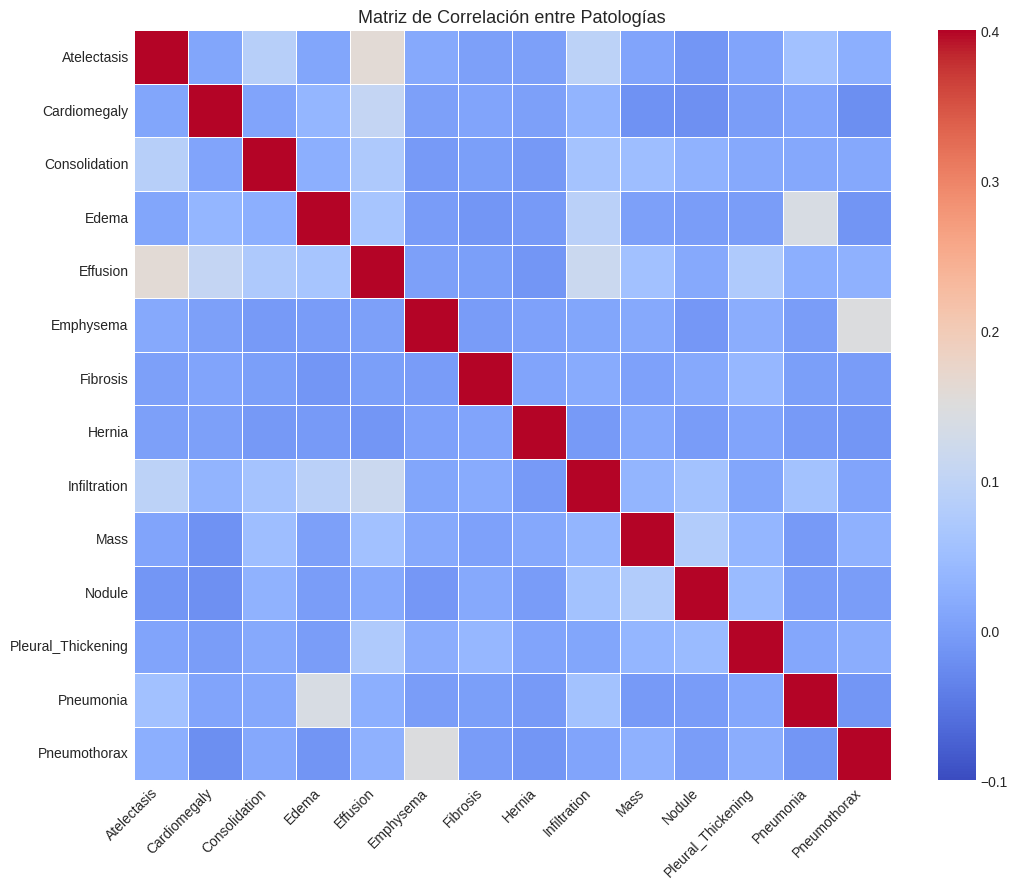

Top 10 correlaciones positivas entre patologías:


,Patología 1,Patología 2,Correlación
0,Atelectasis,Effusion,0.161401
1,Emphysema,Pneumothorax,0.146845
2,Edema,Pneumonia,0.139937
3,Effusion,Infiltration,0.114948
4,Cardiomegaly,Effusion,0.105707
5,Atelectasis,Infiltration,0.093923
6,Edema,Infiltration,0.089575
7,Atelectasis,Consolidation,0.085862
8,Mass,Nodule,0.078622
9,Effusion,Pleural_Thickening,0.074916


In [8]:
# =====================================================
# CELDA 6 - EDA: CORRELACIÓN ENTRE PATOLOGÍAS
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Calcular matriz de correlación entre etiquetas
# -----------------------------------------------------

corr_matrix = df[all_labels].corr()

# -----------------------------------------------------
# 2. Visualizar Heatmap
# -----------------------------------------------------

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-0.10,
    vmax=0.40,
    annot=False,
    linewidths=0.5
)

plt.title(
    "Matriz de Correlación entre Patologías",
    fontsize=13
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. Mostrar las correlaciones positivas más altas
#    excluyendo la diagonal
# -----------------------------------------------------

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Top 10 correlaciones positivas entre patologías:")
display(
    corr_pairs
    .head(10)
    .reset_index()
    .rename(
        columns={
            "level_0": "Patología 1",
            "level_1": "Patología 2",
            0: "Correlación"
        }
    )
)

# -----------------------------------------------------
# MEJORA:
# Además del heatmap, mostramos las asociaciones más
# altas numéricamente. Así evitamos depender únicamente
# de interpretar colores en la matriz.
#
# Nota:
# Esto es una matriz de CORRELACIÓN, no una matriz pura
# de co-ocurrencia.
# -----------------------------------------------------

Registros antes del filtro de edad : 34,999
Registros después del filtro       : 34,998


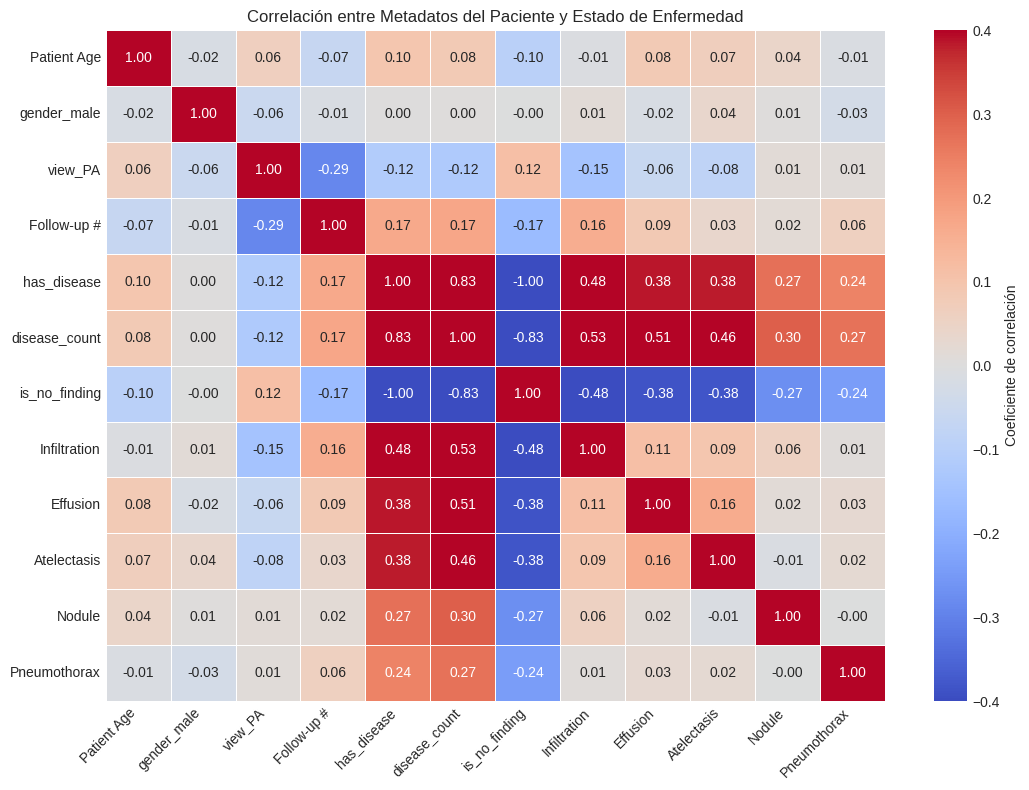

,Estado,total_imagenes,edad_promedio,pct_hombres,pct_vista_PA
0,Sano (No Finding),20353,46.12,53.65,65.55
1,Con Patología(s),14645,49.25,53.77,54.11


In [9]:
# =====================================================
# CELDA 7 - EDA: METADATOS VS ESTADO DE ENFERMEDAD
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------------------------------
# 1. Crear copia para EDA y filtrar edades anómalas
# -----------------------------------------------------

df_eda = df[df["Patient Age"] <= 100].copy()

print(f"Registros antes del filtro de edad : {len(df):,}")
print(f"Registros después del filtro       : {len(df_eda):,}")

# -----------------------------------------------------
# 2. Crear indicadores auxiliares SOLO PARA EDA
# -----------------------------------------------------

df_eda["has_disease"] = (
    df_eda[all_labels].sum(axis=1) > 0
).astype(int)

df_eda["is_no_finding"] = (
    df_eda["has_disease"] == 0
).astype(int)

df_eda["disease_count"] = (
    df_eda[all_labels]
    .sum(axis=1)
    .astype(int)
)

# -----------------------------------------------------
# 3. Codificar metadatos categóricos
# -----------------------------------------------------

df_eda["gender_male"] = (
    df_eda["Patient Gender"] == "M"
).astype(int)

df_eda["view_PA"] = (
    df_eda["View Position"] == "PA"
).astype(int)

# -----------------------------------------------------
# 4. Seleccionar variables de análisis
# -----------------------------------------------------

metadata_vars = [
    "Patient Age",
    "gender_male",
    "view_PA",
]

# Incluir Follow-up # solo si realmente existe
if "Follow-up #" in df_eda.columns:
    metadata_vars.append("Follow-up #")

metadata_vars += [
    "has_disease",
    "disease_count",
    "is_no_finding",
]

# Top 5 patologías más frecuentes
top_diseases = (
    df[all_labels]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

analysis_cols = metadata_vars + top_diseases

# -----------------------------------------------------
# 5. Calcular matriz de correlación
# -----------------------------------------------------

metadata_corr = df_eda[analysis_cols].corr()

# -----------------------------------------------------
# 6. Visualizar Heatmap
# -----------------------------------------------------

plt.figure(figsize=(11, 8))

sns.heatmap(
    metadata_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.4,
    vmax=0.4,
    linewidths=0.5,
    cbar_kws={
        "label": "Coeficiente de correlación"
    }
)

plt.title(
    "Correlación entre Metadatos del Paciente "
    "y Estado de Enfermedad",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 7. Comparación directa: Sin hallazgos vs Patología
# -----------------------------------------------------

summary_metadata = (
    df_eda
    .groupby("has_disease")
    .agg(
        total_imagenes=("Image Index", "count"),
        edad_promedio=("Patient Age", "mean"),
        pct_hombres=(
            "gender_male",
            lambda x: x.mean() * 100
        ),
        pct_vista_PA=(
            "view_PA",
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)

summary_metadata["Estado"] = (
    summary_metadata["has_disease"]
    .map({
        0: "Sano (No Finding)",
        1: "Con Patología(s)"
    })
)

summary_metadata["edad_promedio"] = (
    summary_metadata["edad_promedio"].round(2)
)

summary_metadata["pct_hombres"] = (
    summary_metadata["pct_hombres"].round(2)
)

summary_metadata["pct_vista_PA"] = (
    summary_metadata["pct_vista_PA"].round(2)
)

summary_metadata = summary_metadata[
    [
        "Estado",
        "total_imagenes",
        "edad_promedio",
        "pct_hombres",
        "pct_vista_PA"
    ]
]

display(summary_metadata)

# -----------------------------------------------------
# MEJORA:
# has_disease, disease_count e is_no_finding se crean
# únicamente para análisis exploratorio.
#
# NO se utilizarán como variables de entrada de ResNet50,
# porque derivan directamente de las etiquetas objetivo
# y producirían data leakage.
# -----------------------------------------------------

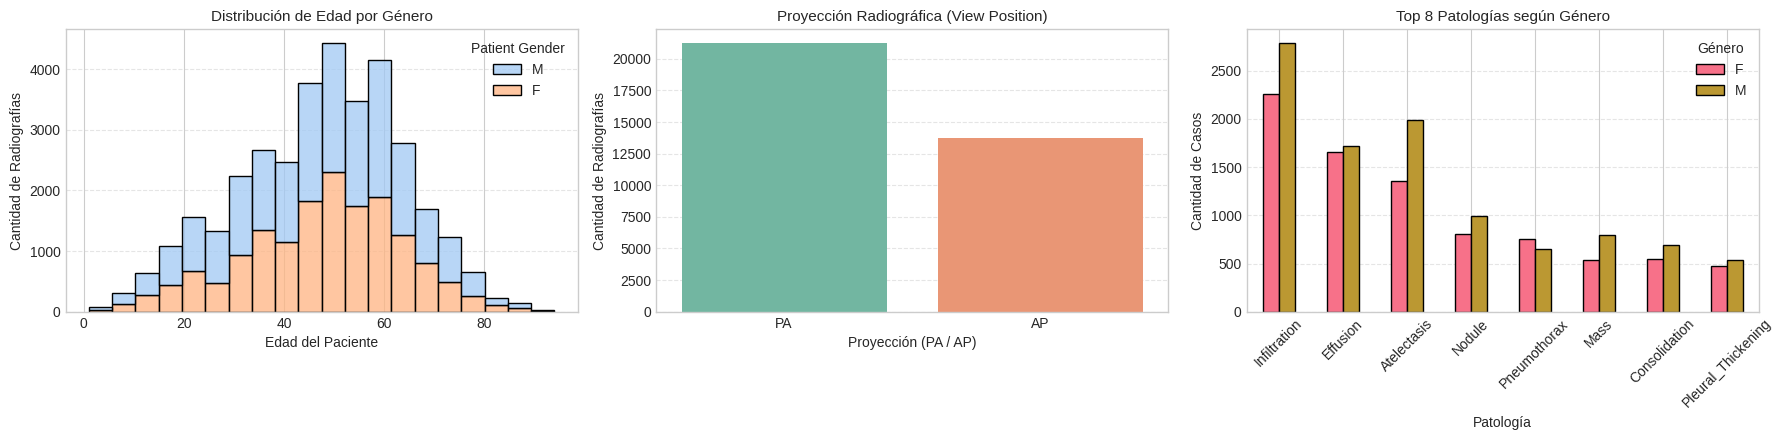

In [10]:
# =====================================================
# CELDA 8 - EDA: DISTRIBUCIÓN DEMOGRÁFICA Y TÉCNICA
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Filtrar edades inconsistentes
# -----------------------------------------------------

df_clean = df[df["Patient Age"] <= 100].copy()

# -----------------------------------------------------
# 2. Crear figura con 3 gráficos
# -----------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 4.5)
)

# -----------------------------------------------------
# A. Distribución de edad por género
# -----------------------------------------------------

sns.histplot(
    data=df_clean,
    x="Patient Age",
    hue="Patient Gender",
    multiple="stack",
    bins=20,
    ax=axes[0],
    palette="pastel"
)

axes[0].set_title(
    "Distribución de Edad por Género",
    fontsize=11
)

axes[0].set_xlabel(
    "Edad del Paciente"
)

axes[0].set_ylabel(
    "Cantidad de Radiografías"
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# -----------------------------------------------------
# B. Distribución de la posición radiográfica
# -----------------------------------------------------

sns.countplot(
    data=df,
    x="View Position",
    hue="View Position",
    ax=axes[1],
    palette="Set2",
    legend=False
)

axes[1].set_title(
    "Proyección Radiográfica (View Position)",
    fontsize=11
)

axes[1].set_xlabel(
    "Proyección (PA / AP)"
)

axes[1].set_ylabel(
    "Cantidad de Radiografías"
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# -----------------------------------------------------
# C. Top 8 patologías según género
# -----------------------------------------------------

gender_disease = (
    df
    .groupby("Patient Gender")[all_labels]
    .sum()
    .T
)

top8_gender = (
    gender_disease
    .assign(
        Total=lambda x: x.sum(axis=1)
    )
    .sort_values(
        by="Total",
        ascending=False
    )
    .head(8)
    .drop(columns="Total")
)

top8_gender.plot(
    kind="bar",
    ax=axes[2],
    edgecolor="black"
)

axes[2].set_title(
    "Top 8 Patologías según Género",
    fontsize=11
)

axes[2].set_xlabel(
    "Patología"
)

axes[2].set_ylabel(
    "Cantidad de Casos"
)

axes[2].tick_params(
    axis="x",
    rotation=45
)

axes[2].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

axes[2].legend(
    title="Género"
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# MEJORA:
# El Top 8 se selecciona usando el total combinado de
# hombres y mujeres, en lugar de ordenar primero por
# una sola categoría de género.
#
# IMPORTANTE:
# Estos son conteos absolutos, NO prevalencias ajustadas.
# Una diferencia entre hombres y mujeres puede deberse
# simplemente a que uno de los grupos tenga más imágenes.
# -----------------------------------------------------

In [11]:
# =====================================================
# CELDA 9 - SPLIT POR PACIENTE
# =====================================================

from sklearn.model_selection import GroupShuffleSplit

# -----------------------------------------------------
# 1. Separar Train (70%) vs Temporal (30%)
#    agrupando por Patient ID
# -----------------------------------------------------

gss_train = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(
    gss_train.split(
        df,
        groups=df["Patient ID"]
    )
)

train_df = (
    df.iloc[train_idx]
    .reset_index(drop=True)
)

temp_df = (
    df.iloc[temp_idx]
    .reset_index(drop=True)
)

# -----------------------------------------------------
# 2. Separar Temporal en Validation (15%) y Test (15%)
# -----------------------------------------------------

gss_val_test = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_SEED
)

val_idx, test_idx = next(
    gss_val_test.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = (
    temp_df.iloc[val_idx]
    .reset_index(drop=True)
)

test_df = (
    temp_df.iloc[test_idx]
    .reset_index(drop=True)
)

# -----------------------------------------------------
# 3. Mostrar tamaños
# -----------------------------------------------------

print(
    f"Train : {len(train_df):,} imágenes | "
    f"{train_df['Patient ID'].nunique():,} pacientes únicos"
)

print(
    f"Val   : {len(val_df):,} imágenes | "
    f"{val_df['Patient ID'].nunique():,} pacientes únicos"
)

print(
    f"Test  : {len(test_df):,} imágenes | "
    f"{test_df['Patient ID'].nunique():,} pacientes únicos"
)

# -----------------------------------------------------
# 4. Calcular porcentajes reales por imágenes
# -----------------------------------------------------

total = len(df)

print("\nDistribución real por imágenes:")

print(
    f"Train : {len(train_df) / total * 100:.2f}%"
)

print(
    f"Val   : {len(val_df) / total * 100:.2f}%"
)

print(
    f"Test  : {len(test_df) / total * 100:.2f}%"
)

# -----------------------------------------------------
# 5. Verificar DATA LEAKAGE entre pacientes
# -----------------------------------------------------

train_patients = set(train_df["Patient ID"])
val_patients = set(val_df["Patient ID"])
test_patients = set(test_df["Patient ID"])

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("\nVerificación de pacientes compartidos:")

print(
    f"Train ↔ Val  : {len(train_val_overlap)}"
)

print(
    f"Train ↔ Test : {len(train_test_overlap)}"
)

print(
    f"Val ↔ Test   : {len(val_test_overlap)}"
)

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✅ No existe fuga de pacientes entre conjuntos.")
else:
    print("\n⚠️ Se detectó solapamiento de pacientes.")

# -----------------------------------------------------
# MEJORA:
# El código anterior comprobaba la intersección de los
# tres conjuntos simultáneamente.
#
# Aquí verificamos cada par:
# Train-Val, Train-Test y Val-Test.
# Esto detecta correctamente cualquier fuga de pacientes.
# -----------------------------------------------------

Train : 24,311 imágenes | 6,462 pacientes únicos
Val   : 5,245 imágenes | 1,385 pacientes únicos
Test  : 5,443 imágenes | 1,385 pacientes únicos

Distribución real por imágenes:
Train : 69.46%
Val   : 14.99%
Test  : 15.55%

Verificación de pacientes compartidos:
Train ↔ Val  : 0
Train ↔ Test : 0
Val ↔ Test   : 0

✅ No existe fuga de pacientes entre conjuntos.


,Patología,Train (%),Validation (%),Test (%)
0,Atelectasis,9.51,9.65,9.70
1,Cardiomegaly,2.95,2.88,2.31
2,Consolidation,3.46,3.81,3.66
3,Edema,1.44,1.37,1.40
4,Effusion,9.43,9.53,10.60
5,Emphysema,2.05,2.25,2.02
6,Fibrosis,1.98,2.55,1.93
7,Hernia,0.28,0.17,0.20
8,Infiltration,14.36,15.41,13.78
9,Mass,3.61,4.84,3.67


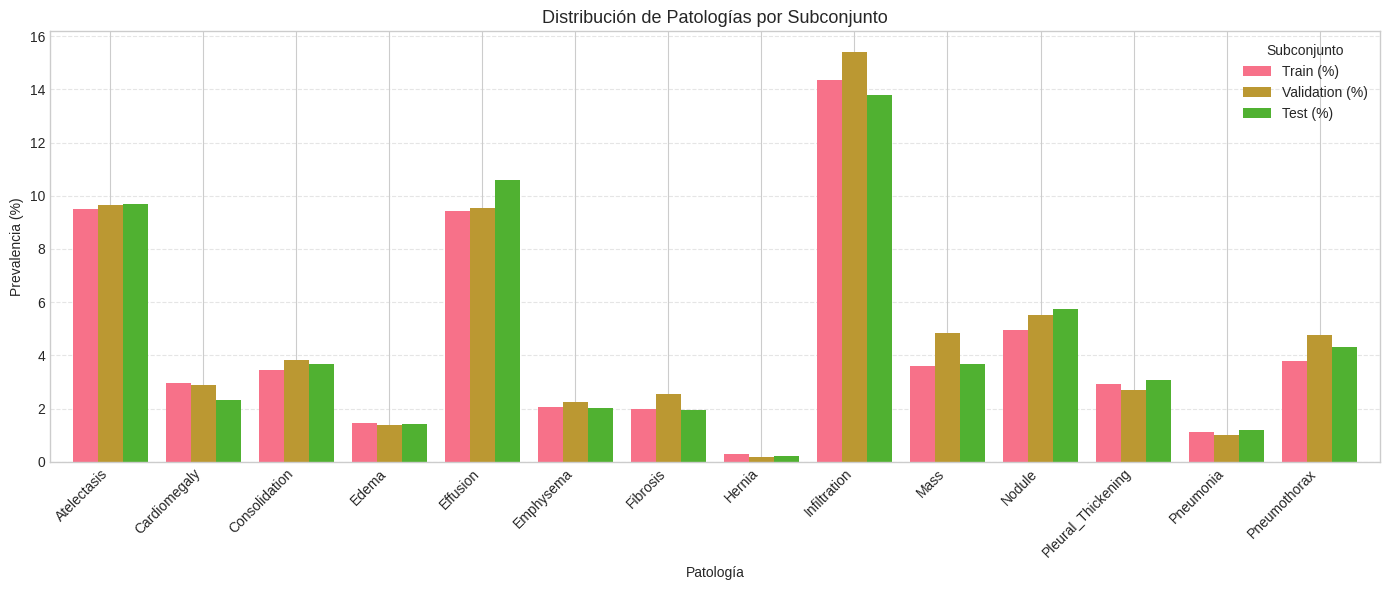

Diferencias máximas de prevalencia entre splits:


,Patología,Diferencia máxima (pp)
8,Infiltration,1.63
9,Mass,1.23
4,Effusion,1.17
13,Pneumothorax,0.98
10,Nodule,0.79
1,Cardiomegaly,0.64
6,Fibrosis,0.62
11,Pleural_Thickening,0.36
2,Consolidation,0.35
5,Emphysema,0.23


In [12]:
# =====================================================
# CELDA 10 - VERIFICAR DISTRIBUCIÓN DE PATOLOGÍAS
# EN TRAIN / VALIDATION / TEST
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------
# 1. Calcular prevalencia (%) de cada patología
#    en cada subconjunto
# -----------------------------------------------------

train_prev = (
    train_df[all_labels].mean() * 100
)

val_prev = (
    val_df[all_labels].mean() * 100
)

test_prev = (
    test_df[all_labels].mean() * 100
)

# -----------------------------------------------------
# 2. Construir tabla comparativa
# -----------------------------------------------------

split_distribution = pd.DataFrame({
    "Patología": all_labels,
    "Train (%)": train_prev.values,
    "Validation (%)": val_prev.values,
    "Test (%)": test_prev.values
})

split_distribution[
    ["Train (%)", "Validation (%)", "Test (%)"]
] = split_distribution[
    ["Train (%)", "Validation (%)", "Test (%)"]
].round(2)

display(split_distribution)

# -----------------------------------------------------
# 3. Graficar comparación
# -----------------------------------------------------

plot_df = split_distribution.set_index("Patología")

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title(
    "Distribución de Patologías por Subconjunto",
    fontsize=13
)

plt.xlabel("Patología")
plt.ylabel("Prevalencia (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.legend(
    title="Subconjunto"
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 4. Calcular máxima diferencia entre conjuntos
# -----------------------------------------------------

split_distribution["Diferencia máxima (pp)"] = (
    split_distribution[
        ["Train (%)", "Validation (%)", "Test (%)"]
    ].max(axis=1)
    -
    split_distribution[
        ["Train (%)", "Validation (%)", "Test (%)"]
    ].min(axis=1)
).round(2)

print("Diferencias máximas de prevalencia entre splits:")
display(
    split_distribution[
        ["Patología", "Diferencia máxima (pp)"]
    ].sort_values(
        by="Diferencia máxima (pp)",
        ascending=False
    )
)

# -----------------------------------------------------
# MEJORA:
# GroupShuffleSplit garantiza separación por paciente,
# pero NO garantiza estratificación multilabel.
#
# Por eso verificamos que Train, Validation y Test
# mantengan distribuciones razonablemente similares
# para las 14 patologías.
# -----------------------------------------------------

In [13]:
# =====================================================
# CELDA 11 - PREPROCESAMIENTO Y GENERADORES RESNET50
# =====================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# -----------------------------------------------------
# 1. Parámetros comunes al experimento DenseNet121
# -----------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------------------------------
# 2. Data Augmentation para entrenamiento
# -----------------------------------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

# -----------------------------------------------------
# 3. Validation y Test:
#    sin augmentation, solo preprocessing de ResNet50
# -----------------------------------------------------

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# -----------------------------------------------------
# 4. Generador de entrenamiento
# -----------------------------------------------------

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=True,
    seed=RANDOM_SEED
)

# -----------------------------------------------------
# 5. Generador de validación
# -----------------------------------------------------

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=False
)

# -----------------------------------------------------
# 6. Generador de test
# -----------------------------------------------------

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=False
)

# -----------------------------------------------------
# 7. Verificaciones
# -----------------------------------------------------

print("\nResumen de generadores:")
print(f"Train      : {train_generator.samples:,} imágenes")
print(f"Validation : {val_generator.samples:,} imágenes")
print(f"Test       : {test_generator.samples:,} imágenes")

print(f"\nTamaño objetivo : {IMG_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Número de clases: {len(all_labels)}")

# -----------------------------------------------------
# MEJORA:
# DenseNet121 había usado rescale=1./255.
#
# Para ResNet50 preentrenado con ImageNet utilizamos
# tf.keras.applications.resnet50.preprocess_input,
# que aplica el preprocessing esperado por los pesos
# preentrenados del backbone.
#
# IMPORTANTE:
# No combinar preprocess_input con rescale=1./255.
# -----------------------------------------------------

Found 24311 validated image filenames.
Found 5245 validated image filenames.
Found 5443 validated image filenames.

Resumen de generadores:
Train      : 24,311 imágenes
Validation : 5,245 imágenes
Test       : 5,443 imágenes

Tamaño objetivo : (224, 224)
Batch size      : 32
Número de clases: 14


In [14]:
# =====================================================
# CELDA 12 - RESNET50 BASE: FEATURE EXTRACTION
# =====================================================

import os
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    BackupAndRestore
)

# -----------------------------------------------------
# 1. Definir carpeta PERSISTENTE en Google Drive
# -----------------------------------------------------

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "Proyecto_Centrum PUCP/ResNet50_results"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

# Ruta permanente del mejor modelo base
BASE_MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "best_resnet50_base.keras"
)

# Carpeta para recuperar entrenamiento interrumpido
BASE_BACKUP_DIR = os.path.join(
    RESULTS_DIR,
    "backup_base_training"
)

os.makedirs(BASE_BACKUP_DIR, exist_ok=True)

print("✅ Resultados persistentes en:")
print(RESULTS_DIR)

# -----------------------------------------------------
# 2. Cargar ResNet50 preentrenado con ImageNet
#    eliminando su clasificador original
# -----------------------------------------------------

resnet50_backbone = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# -----------------------------------------------------
# 3. Congelar completamente el backbone
# -----------------------------------------------------

resnet50_backbone.trainable = False

# -----------------------------------------------------
# 4. Construir cabeza de clasificación multilabel
# -----------------------------------------------------

x = resnet50_backbone.output

x = GlobalAveragePooling2D(
    name="global_avg_pool"
)(x)

x = Dropout(
    0.30,
    name="dropout_regularization"
)(x)

outputs = Dense(
    len(all_labels),
    activation="sigmoid",
    name="multi_label_output"
)(x)

# -----------------------------------------------------
# 5. Construir modelo completo
# -----------------------------------------------------

resnet50_base_model = Model(
    inputs=resnet50_backbone.input,
    outputs=outputs,
    name="ResNet50_NIH_ChestXRay_Base"
)

# -----------------------------------------------------
# 6. Compilar
# -----------------------------------------------------

resnet50_base_model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        AUC(
            multi_label=True,
            num_labels=len(all_labels),
            name="auc_roc_macro"
        ),
        "binary_accuracy"
    ]
)

# -----------------------------------------------------
# 7. Callbacks
# -----------------------------------------------------

base_callbacks = [

    # Guardar permanentemente el mejor modelo en Drive
    ModelCheckpoint(
        filepath=BASE_MODEL_PATH,
        monitor="val_auc_roc_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # Detener si Validation AUC deja de mejorar
    EarlyStopping(
        monitor="val_auc_roc_macro",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    # Reducir learning rate si Validation Loss se estanca
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    # MEJORA:
    # Guarda el estado del entrenamiento en Drive.
    # Si Colab interrumpe el runtime, model.fit() puede
    # continuar desde el último estado respaldado.
    BackupAndRestore(
        backup_dir=BASE_BACKUP_DIR
    )
]

# -----------------------------------------------------
# 8. Verificación de parámetros
# -----------------------------------------------------

total_params = resnet50_base_model.count_params()

trainable_params = int(
    sum(
        tf.keras.backend.count_params(w)
        for w in resnet50_base_model.trainable_weights
    )
)

non_trainable_params = int(
    sum(
        tf.keras.backend.count_params(w)
        for w in resnet50_base_model.non_trainable_weights
    )
)

print(f"\nModelo               : {resnet50_base_model.name}")
print(f"Patologías de salida : {len(all_labels)}")
print(f"Parámetros totales   : {total_params:,}")
print(f"Entrenables          : {trainable_params:,}")
print(f"No entrenables       : {non_trainable_params:,}")

print("\nModelo base se guardará en:")
print(BASE_MODEL_PATH)

print("\nBackup del entrenamiento:")
print(BASE_BACKUP_DIR)

# -----------------------------------------------------
# MEJORA:
# 1. El modelo ya NO se guarda en /content/results.
#    Ahora se guarda permanentemente en Google Drive.
#
# 2. BackupAndRestore protege el progreso ante cortes
#    inesperados de Colab.
#
# 3. Nombre explícito del modelo para evitar confundir
#    posteriormente Base y Fine-Tuned.
#
# 4. Se especifica num_labels=14 en AUC.
# -----------------------------------------------------

✅ Resultados persistentes en:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Modelo               : ResNet50_NIH_ChestXRay_Base
Patologías de salida : 14
Parámetros totales   : 23,616,398
Entrenables          : 28,686
No entrenables       : 23,587,712

Modelo base se guardará en:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Backup del entrenamiento:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/backup_base_training


## ENTRENAMIENTO RESNET50

In [29]:
# =====================================================
# CELDA 13 - ENTRENAMIENTO BASE: FEATURE EXTRACTION
# =====================================================

import os
import numpy as np

# -----------------------------------------------------
# 1. Número máximo de épocas
# -----------------------------------------------------

EPOCHS_BASE = 10

# -----------------------------------------------------
# 2. Verificar si ya existe un modelo base guardado
# -----------------------------------------------------

if os.path.exists(BASE_MODEL_PATH):
    print("⚠️ Ya existe un modelo base guardado en Drive:")
    print(BASE_MODEL_PATH)
    print(
        "\nSi ejecutas model.fit(), se iniciará/continuará "
        "el entrenamiento usando el backup disponible."
    )
else:
    print("No existe todavía un modelo base guardado.")
    print("Se iniciará el entrenamiento.")

# -----------------------------------------------------
# 3. Entrenar modelo
# -----------------------------------------------------

# MEJORA:
# BackupAndRestore está incluido en base_callbacks.
# Si Colab interrumpe el entrenamiento y luego vuelves
# a ejecutar las celdas con el mismo BASE_BACKUP_DIR,
# Keras intentará recuperar el progreso automáticamente.

history_base = resnet50_base_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASE,
    callbacks=base_callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

# -----------------------------------------------------
# 4. Mostrar mejor desempeño alcanzado
# -----------------------------------------------------

best_epoch = (
    np.argmax(
        history_base.history["val_auc_roc_macro"]
    ) + 1
)

best_val_auc = max(
    history_base.history["val_auc_roc_macro"]
)

best_val_loss = min(
    history_base.history["val_loss"]
)

print("\n======================================")
print("RESUMEN DEL ENTRENAMIENTO BASE")
print("======================================")

print(
    f"Mejor época según Validation AUC : "
    f"{best_epoch}"
)

print(
    f"Mejor Validation ROC-AUC         : "
    f"{best_val_auc:.4f}"
)

print(
    f"Menor Validation Loss            : "
    f"{best_val_loss:.4f}"
)

print("\nModelo guardado permanentemente en:")
print(BASE_MODEL_PATH)

# -----------------------------------------------------
# 5. Verificar que el modelo realmente exista en Drive
# -----------------------------------------------------

if os.path.exists(BASE_MODEL_PATH):

    model_size_mb = (
        os.path.getsize(BASE_MODEL_PATH)
        / (1024 ** 2)
    )

    print("\n✅ Modelo confirmado en Google Drive.")
    print(
        f"Tamaño del archivo: "
        f"{model_size_mb:.2f} MB"
    )

else:
    print(
        "\n⚠️ El archivo del modelo no fue encontrado "
        "en Google Drive."
    )

# -----------------------------------------------------
# MEJORA:
# 1. El mejor checkpoint queda en Drive.
#
# 2. Se verifica físicamente que el .keras exista.
#
# 3. Se muestra su tamaño para comprobar que realmente
#    fue escrito y no estamos confiando ciegamente en
#    que Colab hizo lo que decía.
#
# 4. BackupAndRestore permite proteger el entrenamiento
#    ante interrupciones del runtime.
# -----------------------------------------------------

No existe todavía un modelo base guardado.
Se iniciará el entrenamiento.
Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - auc_roc_macro: 0.5793 - binary_accuracy: 0.9468 - loss: 0.1935
Epoch 1: val_auc_roc_macro improved from None to 0.66802, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 893s 1s/step - auc_roc_macro: 0.6177 - binary_accuracy: 0.9529 - loss: 0.1736 - val_auc_roc_macro: 0.6680 - val_binary_accuracy: 0.9525 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.6716 - binary_accuracy: 0.9548 - loss: 0.1606
Epoch 2: val_auc_roc_macro improved from 0.66802 to 0.68242, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Epoch 2: finished saving model to /c

In [15]:
# =====================================================
# CELDA 14 - PREPARAR RESNET50 PARA FINE-TUNING
# =====================================================

import os
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# -----------------------------------------------------
# 1. Ruta permanente del mejor modelo Base
# -----------------------------------------------------

BASE_MODEL_PATH = (
    "/content/drive/MyDrive/Proyecto_Centrum PUCP/"
    "ResNet50_results/best_resnet50_base.keras"
)

FT_MODEL_PATH = (
    "/content/drive/MyDrive/Proyecto_Centrum PUCP/"
    "ResNet50_results/best_resnet50_finetuned.keras"
)

# Verificar existencia
if not os.path.exists(BASE_MODEL_PATH):
    raise FileNotFoundError(
        f"❌ No se encontró el modelo Base en:\n{BASE_MODEL_PATH}"
    )

print("✅ Modelo Base encontrado.")

# -----------------------------------------------------
# 2. Cargar el mejor ResNet50 Base
# -----------------------------------------------------

resnet50_ft_model = load_model(BASE_MODEL_PATH)

print(f"✅ Modelo cargado: {resnet50_ft_model.name}")

# -----------------------------------------------------
# 3. Congelar primero TODAS las capas
# -----------------------------------------------------

for layer in resnet50_ft_model.layers:
    layer.trainable = False

# -----------------------------------------------------
# 4. Descongelar únicamente el bloque conv5_x
# -----------------------------------------------------

for layer in resnet50_ft_model.layers:

    if layer.name.startswith("conv5_"):

        # MEJORA:
        # Las capas BatchNormalization permanecen
        # congeladas durante el Fine-Tuning.
        if not isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = True

# -----------------------------------------------------
# 5. Mantener entrenable la cabeza clasificadora
# -----------------------------------------------------

for layer_name in [
    "global_avg_pool",
    "dropout_regularization",
    "multi_label_output"
]:
    layer = resnet50_ft_model.get_layer(layer_name)
    layer.trainable = True

# -----------------------------------------------------
# 6. Contar capas entrenables y congeladas
# -----------------------------------------------------

trainable_layers = [
    layer.name
    for layer in resnet50_ft_model.layers
    if layer.trainable
]

frozen_layers = [
    layer.name
    for layer in resnet50_ft_model.layers
    if not layer.trainable
]

print("\nConfiguración para Fine-Tuning:")
print(f"Capas entrenables : {len(trainable_layers)}")
print(f"Capas congeladas  : {len(frozen_layers)}")

print("\nPrimeras capas entrenables detectadas:")

for name in trainable_layers[:15]:
    print(" -", name)

# -----------------------------------------------------
# 7. Recompilar con Learning Rate pequeño
# -----------------------------------------------------

resnet50_ft_model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        AUC(
            multi_label=True,
            num_labels=len(all_labels),
            name="auc_roc_macro"
        ),
        "binary_accuracy"
    ]
)

print("\n✅ Modelo recompilado para Fine-Tuning.")
print("Learning Rate: 1e-5")

# -----------------------------------------------------
# MEJORA:
#
# DenseNet121 descongeló simplemente las últimas
# 35 capas.
#
# Para ResNet50 usamos una estrategia arquitectónica:
#
# conv1
# conv2_x     → congelado
# conv3_x     → congelado
# conv4_x     → congelado
# conv5_x     → entrenable
#
# Además mantenemos BatchNormalization congelada.
#
# Esto es más justificable que seleccionar un número
# arbitrario de capas.
# -----------------------------------------------------

✅ Modelo Base encontrado.
✅ Modelo cargado: ResNet50_NIH_ChestXRay_Base

Configuración para Fine-Tuning:
Capas entrenables : 25
Capas congeladas  : 153

Primeras capas entrenables detectadas:
 - conv5_block1_1_conv
 - conv5_block1_1_relu
 - conv5_block1_2_conv
 - conv5_block1_2_relu
 - conv5_block1_0_conv
 - conv5_block1_3_conv
 - conv5_block1_add
 - conv5_block1_out
 - conv5_block2_1_conv
 - conv5_block2_1_relu
 - conv5_block2_2_conv
 - conv5_block2_2_relu
 - conv5_block2_3_conv
 - conv5_block2_add
 - conv5_block2_out

✅ Modelo recompilado para Fine-Tuning.
Learning Rate: 1e-5


## ENTRENAMIENTO FINE-TUNING RESNET50

In [20]:
# =====================================================
# CELDA 15 - ENTRENAMIENTO FINE-TUNING RESNET50
# =====================================================

import os
import numpy as np

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# -----------------------------------------------------
# 1. Número máximo de épocas de Fine-Tuning
# -----------------------------------------------------

EPOCHS_FINE_TUNE = 5

# -----------------------------------------------------
# 2. Callbacks específicos para Fine-Tuning
# -----------------------------------------------------

fine_tune_callbacks = [

    ModelCheckpoint(
        filepath=FT_MODEL_PATH,
        monitor="val_auc_roc_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_auc_roc_macro",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# -----------------------------------------------------
# 3. Entrenamiento Fine-Tuning
# -----------------------------------------------------

print("======================================")
print("INICIO DEL FINE-TUNING")
print("======================================")

print(f"Épocas máximas      : {EPOCHS_FINE_TUNE}")
print("Learning Rate inicial: 1e-5")
print(f"Modelo de salida    : {FT_MODEL_PATH}")

history_fine_tune = resnet50_ft_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=fine_tune_callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

# -----------------------------------------------------
# 4. Obtener mejor época
# -----------------------------------------------------

best_ft_epoch = (
    np.argmax(
        history_fine_tune.history["val_auc_roc_macro"]
    ) + 1
)

best_ft_val_auc = max(
    history_fine_tune.history["val_auc_roc_macro"]
)

best_ft_val_loss = min(
    history_fine_tune.history["val_loss"]
)

# -----------------------------------------------------
# 5. Mostrar resumen
# -----------------------------------------------------

print("\n======================================")
print("RESUMEN DEL FINE-TUNING")
print("======================================")

print(
    f"Mejor época según Validation AUC : "
    f"{best_ft_epoch}"
)

print(
    f"Mejor Validation ROC-AUC         : "
    f"{best_ft_val_auc:.4f}"
)

print(
    f"Menor Validation Loss            : "
    f"{best_ft_val_loss:.4f}"
)

print("\nModelo Fine-Tuned guardado en:")
print(FT_MODEL_PATH)

# -----------------------------------------------------
# 6. Verificar archivo
# -----------------------------------------------------

if os.path.exists(FT_MODEL_PATH):

    size_mb = (
        os.path.getsize(FT_MODEL_PATH)
        / (1024 ** 2)
    )

    print("\n✅ Modelo Fine-Tuned confirmado en Google Drive.")
    print(f"Tamaño del archivo: {size_mb:.2f} MB")

else:

    print(
        "\n⚠️ No se encontró el archivo Fine-Tuned "
        "en Google Drive."
    )

# -----------------------------------------------------
# MEJORA:
#
# 1. El modelo se guarda directamente en Google Drive.
#    Así no repetimos la alegre experiencia de perderlo
#    cuando Colab reinicia /content/.
#
# 2. Fine-Tuning se limita inicialmente a 5 épocas.
#
# 3. Utilizamos EarlyStopping para evitar seguir
#    entrenando si Validation deja de mejorar.
#
# 4. ReduceLROnPlateau puede bajar todavía más el LR
#    si la pérdida de Validation se estanca.
#
# 5. El mejor modelo se selecciona por
#    val_auc_roc_macro, igual que en la fase Base.
# -----------------------------------------------------

INICIO DEL FINE-TUNING
Épocas máximas      : 5
Learning Rate inicial: 1e-5
Modelo de salida    : /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras
Epoch 1/5
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.7665 - binary_accuracy: 0.9560 - loss: 0.1452
Epoch 1: val_auc_roc_macro improved from None to 0.72913, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 948s 1s/step - auc_roc_macro: 0.7695 - binary_accuracy: 0.9559 - loss: 0.1452 - val_auc_roc_macro: 0.7291 - val_binary_accuracy: 0.9521 - val_loss: 0.1595 - learning_rate: 1.0000e-05
Epoch 2/5
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.7901 - binary_accuracy: 0.9557 - loss: 0.1425
Epoch 2: val_auc_roc_macro improved from 0.72913 to 0.73672, saving model to

In [17]:
# =====================================================
# CELDA 16 - EVALUACIÓN DEL MODELO FINE-TUNED EN TEST
# =====================================================

import numpy as np
import pandas as pd

from tensorflow.keras.models import load_model
from sklearn.metrics import roc_auc_score

# -----------------------------------------------------
# 1. Cargar explícitamente el mejor modelo Fine-Tuned
# -----------------------------------------------------

resnet50_best_ft = load_model(
    FT_MODEL_PATH
)

print(
    f"✅ Modelo cargado: "
    f"{resnet50_best_ft.name}"
)

# -----------------------------------------------------
# 2. Reiniciar generador de Test
# -----------------------------------------------------

test_generator.reset()

# -----------------------------------------------------
# 3. Obtener probabilidades sobre Test
# -----------------------------------------------------

print("\nGenerando predicciones sobre Test...")

y_test_probs = resnet50_best_ft.predict(
    test_generator,
    verbose=1
)

print(
    f"\nForma de las predicciones: "
    f"{y_test_probs.shape}"
)

# -----------------------------------------------------
# 4. Obtener etiquetas reales
# -----------------------------------------------------

y_test_true = (
    test_df[all_labels]
    .values
    .astype(int)
)

print(
    f"Forma de etiquetas reales: "
    f"{y_test_true.shape}"
)

# -----------------------------------------------------
# 5. ROC-AUC por patología
# -----------------------------------------------------

auc_results = []

for i, label in enumerate(all_labels):

    auc_value = roc_auc_score(
        y_test_true[:, i],
        y_test_probs[:, i]
    )

    auc_results.append(
        {
            "Patología": label,
            "ROC-AUC": auc_value
        }
    )

auc_df = pd.DataFrame(
    auc_results
).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

# -----------------------------------------------------
# 6. Macro ROC-AUC
# -----------------------------------------------------

macro_auc = roc_auc_score(
    y_test_true,
    y_test_probs,
    average="macro"
)

print("\n======================================")
print("RESULTADOS RESNET50 FINE-TUNED - TEST")
print("======================================")

display(
    auc_df.style.format(
        {
            "ROC-AUC": "{:.4f}"
        }
    )
)

print(
    f"\nMacro ROC-AUC Test: "
    f"{macro_auc:.4f}"
)

# -----------------------------------------------------
# MEJORA:
#
# 1. Se carga explícitamente el archivo Fine-Tuned.
#    Así evitamos confundirlo con el modelo Base.
#
# 2. Test se utiliza únicamente para evaluación.
#    No se ajusta ningún hiperparámetro aquí.
#
# 3. El Macro ROC-AUC se calcula directamente sobre
#    las 14 patologías reales.
#
# No incluimos "No Finding" como una clase artificial.
# -----------------------------------------------------

✅ Modelo cargado: ResNet50_NIH_ChestXRay_Base

Generando predicciones sobre Test...
171/171 ━━━━━━━━━━━━━━━━━━━━ 650s 4s/step

Forma de las predicciones: (5443, 14)
Forma de etiquetas reales: (5443, 14)

RESULTADOS RESNET50 FINE-TUNED - TEST


,Patología,ROC-AUC
0,Cardiomegaly,0.8653
1,Edema,0.8643
2,Effusion,0.8296
3,Pneumothorax,0.7903
4,Emphysema,0.7825
5,Fibrosis,0.7759
6,Atelectasis,0.7591
7,Hernia,0.7550
8,Infiltration,0.7322
9,Consolidation,0.7320



Macro ROC-AUC Test: 0.7546


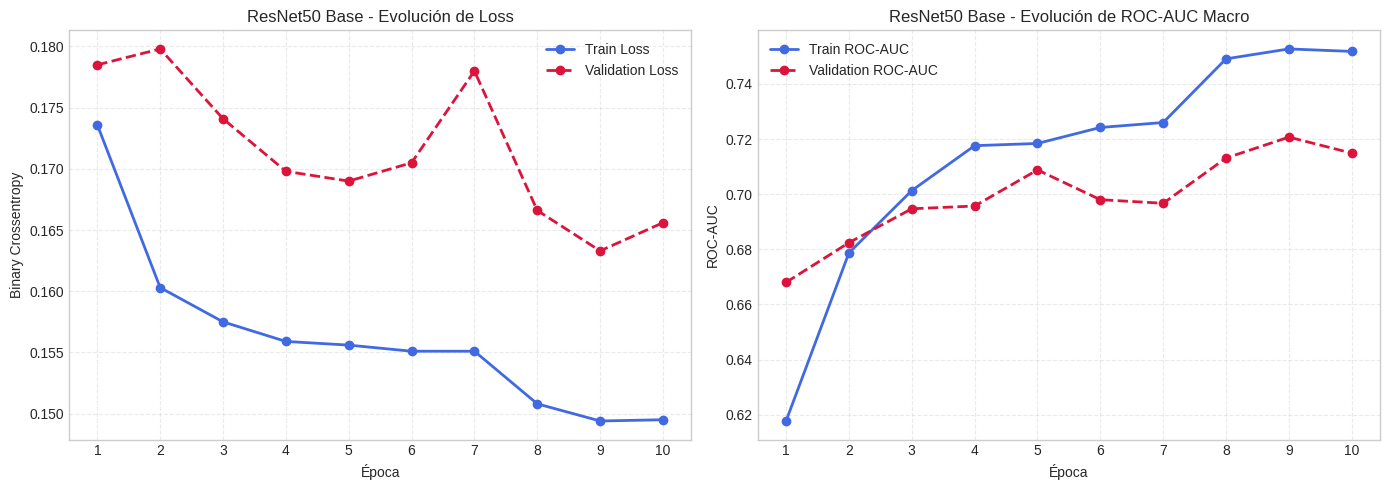

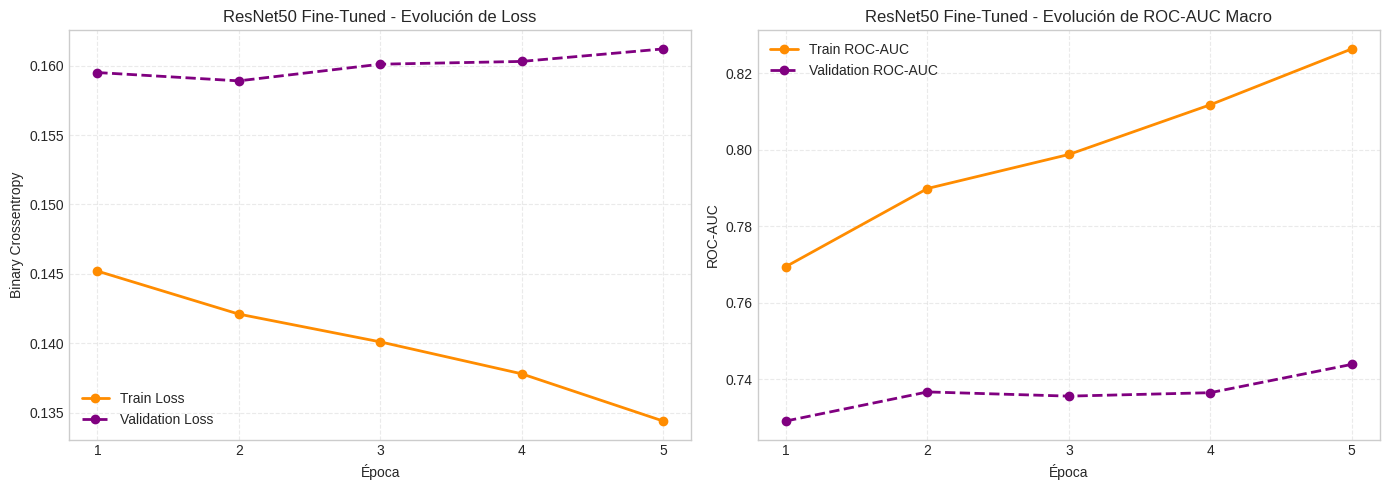

In [23]:
# =====================================================
# CURVAS DE ENTRENAMIENTO RESNET50
# MODELO BASE + FINE-TUNING
# Reconstruidas con los resultados reales obtenidos
# =====================================================

import matplotlib.pyplot as plt

# =====================================================
# 1. RESULTADOS REALES - RESNET50 BASE
# =====================================================

epochs_base = list(range(1, 11))

base_train_loss = [
    0.1736,
    0.1603,
    0.1575,
    0.1559,
    0.1556,
    0.1551,
    0.1551,
    0.1508,
    0.1494,
    0.1495
]

base_val_loss = [
    0.1785,
    0.1798,
    0.1741,
    0.1698,
    0.1690,
    0.1705,
    0.1780,
    0.1666,
    0.1633,
    0.1656
]

base_train_auc = [
    0.6177,
    0.6787,
    0.7013,
    0.7176,
    0.7184,
    0.7242,
    0.7260,
    0.7491,
    0.7527,
    0.7518
]

base_val_auc = [
    0.6680,
    0.6824,
    0.6947,
    0.6957,
    0.7088,
    0.6980,
    0.6967,
    0.7131,
    0.7207,
    0.7149
]


# =====================================================
# 2. RESULTADOS REALES - RESNET50 FINE-TUNING
# =====================================================

epochs_ft = list(range(1, 6))

ft_train_loss = [
    0.1452,
    0.1421,
    0.1401,
    0.1378,
    0.1344
]

ft_val_loss = [
    0.1595,
    0.1589,
    0.1601,
    0.1603,
    0.1612
]

ft_train_auc = [
    0.7695,
    0.7899,
    0.7988,
    0.8118,
    0.8264
]

ft_val_auc = [
    0.7291,
    0.7367,
    0.7356,
    0.7365,
    0.7439
]


# =====================================================
# 3. CURVAS MODELO BASE
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss
axes[0].plot(
    epochs_base,
    base_train_loss,
    label="Train Loss",
    color="royalblue",
    linewidth=2,
    marker="o"
)

axes[0].plot(
    epochs_base,
    base_val_loss,
    label="Validation Loss",
    color="crimson",
    linewidth=2,
    linestyle="--",
    marker="o"
)

axes[0].set_title(
    "ResNet50 Base - Evolución de Loss"
)

axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].set_xticks(epochs_base)

axes[0].legend()

axes[0].grid(
    True,
    linestyle="--",
    alpha=0.4
)


# ROC-AUC
axes[1].plot(
    epochs_base,
    base_train_auc,
    label="Train ROC-AUC",
    color="royalblue",
    linewidth=2,
    marker="o"
)

axes[1].plot(
    epochs_base,
    base_val_auc,
    label="Validation ROC-AUC",
    color="crimson",
    linewidth=2,
    linestyle="--",
    marker="o"
)

axes[1].set_title(
    "ResNet50 Base - Evolución de ROC-AUC Macro"
)

axes[1].set_xlabel("Época")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xticks(epochs_base)

axes[1].legend()

axes[1].grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# =====================================================
# 4. CURVAS FINE-TUNING
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss
axes[0].plot(
    epochs_ft,
    ft_train_loss,
    label="Train Loss",
    color="darkorange",
    linewidth=2,
    marker="o"
)

axes[0].plot(
    epochs_ft,
    ft_val_loss,
    label="Validation Loss",
    color="purple",
    linewidth=2,
    linestyle="--",
    marker="o"
)

axes[0].set_title(
    "ResNet50 Fine-Tuned - Evolución de Loss"
)

axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].set_xticks(epochs_ft)

axes[0].legend()

axes[0].grid(
    True,
    linestyle="--",
    alpha=0.4
)


# ROC-AUC
axes[1].plot(
    epochs_ft,
    ft_train_auc,
    label="Train ROC-AUC",
    color="darkorange",
    linewidth=2,
    marker="o"
)

axes[1].plot(
    epochs_ft,
    ft_val_auc,
    label="Validation ROC-AUC",
    color="purple",
    linewidth=2,
    linestyle="--",
    marker="o"
)

axes[1].set_title(
    "ResNet50 Fine-Tuned - Evolución de ROC-AUC Macro"
)

axes[1].set_xlabel("Época")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xticks(epochs_ft)

axes[1].legend()

axes[1].grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

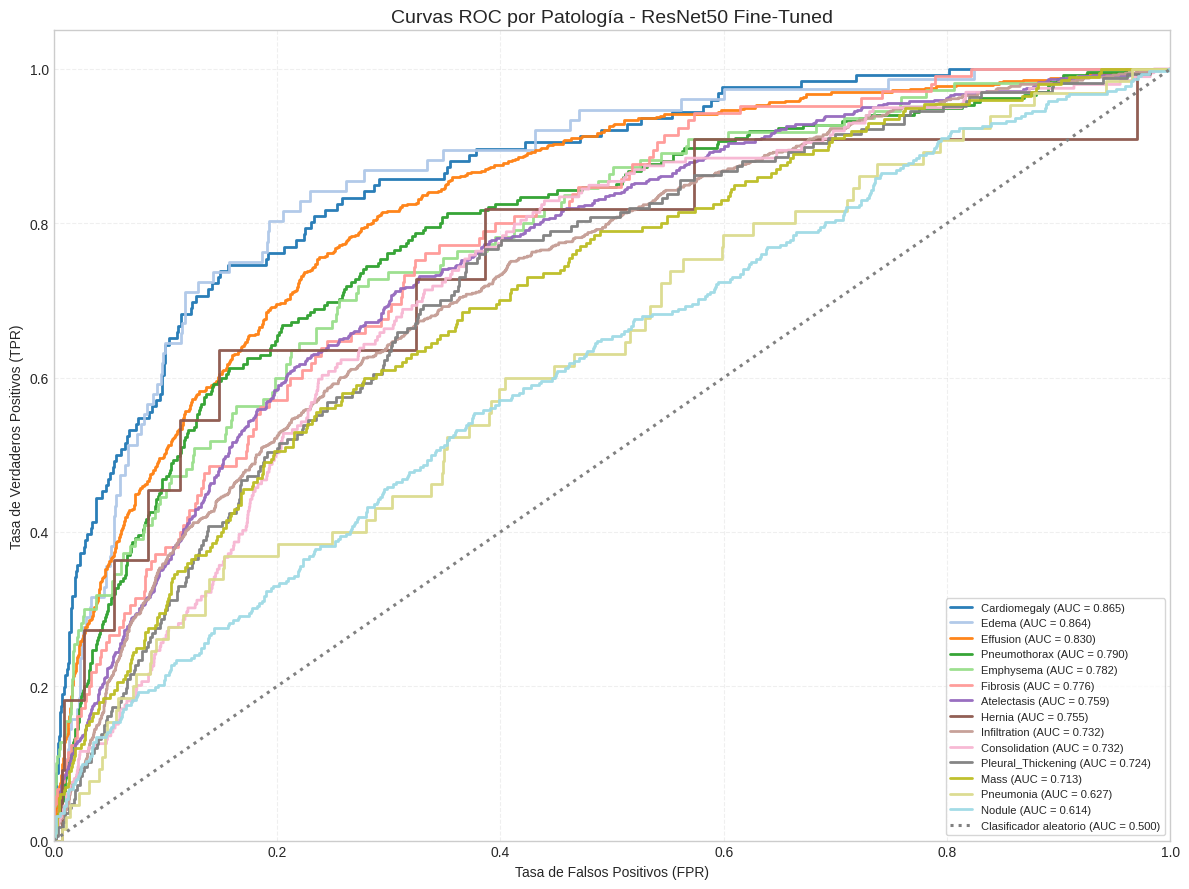

,Patología,ROC-AUC
0,Cardiomegaly,0.8653
1,Edema,0.8643
2,Effusion,0.8296
3,Pneumothorax,0.7903
4,Emphysema,0.7825
5,Fibrosis,0.7759
6,Atelectasis,0.7591
7,Hernia,0.7550
8,Infiltration,0.7322
9,Consolidation,0.7320



Macro ROC-AUC Test: 0.7546


In [20]:
# =====================================================
# CELDA 18 - CURVAS ROC POR PATOLOGÍA EN TEST
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import roc_curve, auc

# -----------------------------------------------------
# 1. Calcular ROC y AUC por patología
# -----------------------------------------------------

roc_data = []

for i, label in enumerate(all_labels):

    fpr, tpr, thresholds = roc_curve(
        y_test_true[:, i],
        y_test_probs[:, i]
    )

    class_auc = auc(fpr, tpr)

    roc_data.append({
        "Patología": label,
        "ROC-AUC": class_auc,
        "FPR": fpr,
        "TPR": tpr
    })

# -----------------------------------------------------
# 2. Ordenar de MAYOR a MENOR ROC-AUC
# -----------------------------------------------------

roc_data = sorted(
    roc_data,
    key=lambda x: x["ROC-AUC"],
    reverse=True
)

# -----------------------------------------------------
# 3. Crear una paleta con 14 colores diferentes
# -----------------------------------------------------

# tab20 contiene 20 tonos suficientemente distintos.
# Tomamos 14 posiciones distribuidas a lo largo
# de toda la paleta para evitar colores repetidos.

cmap = plt.get_cmap("tab20")

colors = [
    cmap(i)
    for i in np.linspace(
        0,
        19,
        len(roc_data),
        dtype=int
    )
]

# -----------------------------------------------------
# 4. Graficar curvas ROC
# -----------------------------------------------------

plt.figure(figsize=(12, 9))

for item, color in zip(roc_data, colors):

    plt.plot(
        item["FPR"],
        item["TPR"],
        color=color,
        linewidth=2.0,
        alpha=0.95,
        label=(
            f"{item['Patología']} "
            f"(AUC = {item['ROC-AUC']:.3f})"
        )
    )

# -----------------------------------------------------
# 5. Clasificador aleatorio
# -----------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    color="gray",
    linewidth=2.2,
    label="Clasificador aleatorio (AUC = 0.500)"
)

# -----------------------------------------------------
# 6. Configuración del gráfico
# -----------------------------------------------------

plt.title(
    "Curvas ROC por Patología - ResNet50 Fine-Tuned",
    fontsize=14
)

plt.xlabel(
    "Tasa de Falsos Positivos (FPR)"
)

plt.ylabel(
    "Tasa de Verdaderos Positivos (TPR)"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(
    loc="lower right",
    fontsize=8,
    frameon=True
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 7. Tabla resumen ordenada
# -----------------------------------------------------

roc_summary = pd.DataFrame(
    {
        "Patología": [
            item["Patología"]
            for item in roc_data
        ],
        "ROC-AUC": [
            item["ROC-AUC"]
            for item in roc_data
        ]
    }
)

display(
    roc_summary.style.format(
        {
            "ROC-AUC": "{:.4f}"
        }
    )
)

print(
    f"\nMacro ROC-AUC Test: "
    f"{roc_summary['ROC-AUC'].mean():.4f}"
)

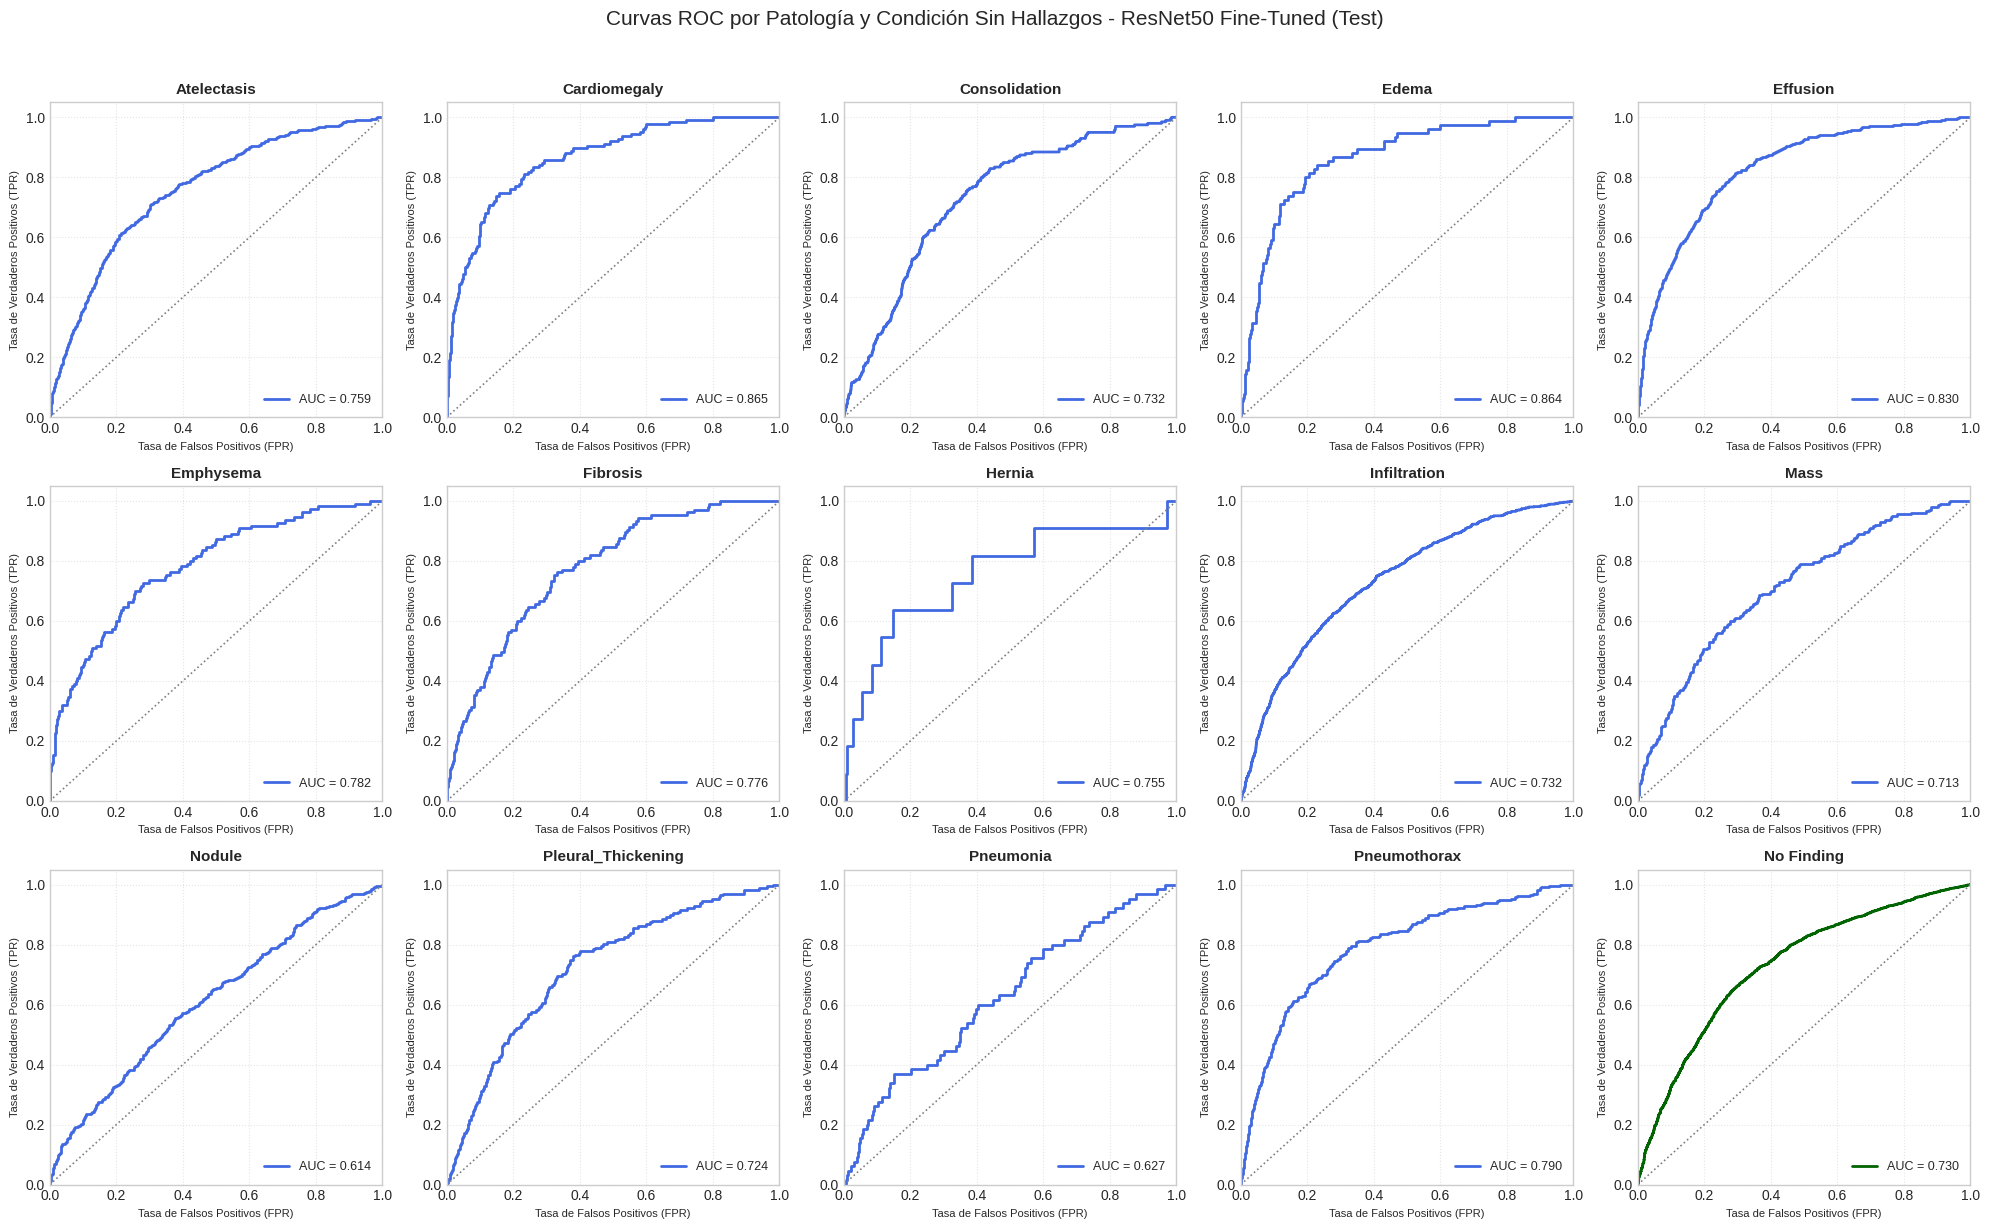

ROC-AUC POR CONDICIÓN
Cardiomegaly              : 0.8653
Edema                     : 0.8643
Effusion                  : 0.8296
Pneumothorax              : 0.7903
Emphysema                 : 0.7825
Fibrosis                  : 0.7759
Atelectasis               : 0.7591
Hernia                    : 0.7550
Infiltration              : 0.7322
Consolidation             : 0.7320
No Finding                : 0.7297
Pleural_Thickening        : 0.7241
Mass                      : 0.7127
Pneumonia                 : 0.6274
Nodule                    : 0.6142


In [21]:
# =====================================================
# CELDA 19 - CURVAS ROC INDIVIDUALES POR PATOLOGÍA
# + CONDICIÓN "NO FINDING"
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# -----------------------------------------------------
# 1. Usar las predicciones YA obtenidas del modelo FT
# -----------------------------------------------------

# y_test_probs  -> probabilidades Fine-Tuned en Test
# y_test_true   -> etiquetas reales de Test

y_pred_probs = y_test_probs
y_true = y_test_true

# -----------------------------------------------------
# 2. Construir la clase real "No Finding"
# -----------------------------------------------------

# 1 = ninguna de las 14 patologías está presente
# 0 = existe al menos una patología

y_true_no_finding = (
    y_true.sum(axis=1) == 0
).astype(int)

# -----------------------------------------------------
# 3. Aproximación de probabilidad "No Finding"
# -----------------------------------------------------

# Se aproxima como la probabilidad conjunta de que
# ninguna de las 14 patologías esté presente.

y_pred_no_finding = np.prod(
    1.0 - y_pred_probs,
    axis=1
)

# -----------------------------------------------------
# 4. Consolidar las 15 condiciones
# -----------------------------------------------------

eval_labels = (
    list(all_labels)
    + ["No Finding"]
)

y_true_all = np.column_stack([
    y_true,
    y_true_no_finding
])

y_pred_all = np.column_stack([
    y_pred_probs,
    y_pred_no_finding
])

# -----------------------------------------------------
# 5. Crear cuadrícula 3 x 5
# -----------------------------------------------------

fig, axes = plt.subplots(
    3,
    5,
    figsize=(20, 12)
)

axes = axes.ravel()

# -----------------------------------------------------
# 6. Dibujar ROC individual
# -----------------------------------------------------

roc_individual_results = {}

for idx, label in enumerate(eval_labels):

    fpr, tpr, _ = roc_curve(
        y_true_all[:, idx],
        y_pred_all[:, idx]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    roc_individual_results[label] = roc_auc

    ax = axes[idx]

    # No Finding en verde oscuro;
    # patologías en azul
    line_color = (
        "darkgreen"
        if label == "No Finding"
        else "royalblue"
    )

    ax.plot(
        fpr,
        tpr,
        color=line_color,
        linewidth=2,
        label=f"AUC = {roc_auc:.3f}"
    )

    # Clasificador aleatorio
    ax.plot(
        [0, 1],
        [0, 1],
        color="gray",
        linewidth=1.2,
        linestyle=":"
    )

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])

    ax.set_title(
        label,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Tasa de Falsos Positivos (FPR)",
        fontsize=8
    )

    ax.set_ylabel(
        "Tasa de Verdaderos Positivos (TPR)",
        fontsize=8
    )

    ax.legend(
        loc="lower right",
        fontsize=9
    )

    ax.grid(
        True,
        linestyle=":",
        alpha=0.5
    )

# -----------------------------------------------------
# 7. Título general
# -----------------------------------------------------

plt.suptitle(
    "Curvas ROC por Patología y Condición Sin Hallazgos "
    "- ResNet50 Fine-Tuned (Test)",
    fontsize=15,
    y=1.02
)

plt.tight_layout()

plt.show()

# -----------------------------------------------------
# 8. Mostrar AUC por condición
# -----------------------------------------------------

print("======================================")
print("ROC-AUC POR CONDICIÓN")
print("======================================")

for label, value in sorted(
    roc_individual_results.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{label:<25} : {value:.4f}"
    )

# -----------------------------------------------------
# IMPORTANTE:
#
# "No Finding" NO es una salida directa del modelo.
#
# y_pred_no_finding se construye mediante:
#
#     prod(1 - p_i)
#
# Esto supone implícitamente independencia entre las
# probabilidades de las patologías, lo cual no es
# completamente cierto en un problema multilabel.
#
# Por eso debe reportarse como una aproximación
# sintética y no como una clase aprendida directamente
# por ResNet50.
# -----------------------------------------------------

In [25]:
# =====================================================
# CELDA 20 - PREDICCIONES FINE-TUNED EN VALIDATION
# =====================================================

import numpy as np
from tensorflow.keras.models import load_model

# -----------------------------------------------------
# 1. Cargar explícitamente el modelo Fine-Tuned
# -----------------------------------------------------

resnet50_best_ft = load_model(
    FT_MODEL_PATH
)

print(
    f"✅ Modelo cargado: "
    f"{resnet50_best_ft.name}"
)

print(
    f"Archivo utilizado: "
    f"{FT_MODEL_PATH}"
)

# -----------------------------------------------------
# 2. Reiniciar generador de Validation
# -----------------------------------------------------

val_generator.reset()

# -----------------------------------------------------
# 3. Obtener probabilidades sobre Validation
# -----------------------------------------------------

print("\nGenerando predicciones sobre Validation...")

y_val_probs = resnet50_best_ft.predict(
    val_generator,
    verbose=1
)

# -----------------------------------------------------
# 4. Obtener etiquetas reales de Validation
# -----------------------------------------------------

y_val_true = (
    val_df[all_labels]
    .values
    .astype(int)
)

# -----------------------------------------------------
# 5. Verificaciones
# -----------------------------------------------------

print(
    f"\nForma de las predicciones: "
    f"{y_val_probs.shape}"
)

print(
    f"Forma de etiquetas reales: "
    f"{y_val_true.shape}"
)

print(
    f"Número de patologías: "
    f"{len(all_labels)}"
)

# -----------------------------------------------------
# 6. Verificar rango de probabilidades
# -----------------------------------------------------

print(
    f"\nProbabilidad mínima: "
    f"{y_val_probs.min():.6f}"
)

print(
    f"Probabilidad máxima: "
    f"{y_val_probs.max():.6f}"
)

# -----------------------------------------------------
# MEJORA:
#
# Los thresholds se calibrarán EXCLUSIVAMENTE usando
# Validation.
#
# Test no participa en la selección de thresholds.
# Así evitamos data leakage durante la evaluación final.
# -----------------------------------------------------

✅ Modelo cargado: ResNet50_NIH_ChestXRay_Base
Archivo utilizado: /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras

Generando predicciones sobre Validation...
164/164 ━━━━━━━━━━━━━━━━━━━━ 633s 4s/step

Forma de las predicciones: (5245, 14)
Forma de etiquetas reales: (5245, 14)
Número de patologías: 14

Probabilidad mínima: 0.000000
Probabilidad máxima: 0.964500


In [26]:
# =====================================================
# CELDA 21 - CALIBRACIÓN DE THRESHOLDS EN VALIDATION
# =====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_curve,
    f1_score
)

# -----------------------------------------------------
# 1. Diccionario para guardar thresholds óptimos
# -----------------------------------------------------

optimal_thresholds = {}

threshold_results = []

# -----------------------------------------------------
# 2. Calibrar threshold por cada patología
# -----------------------------------------------------

for i, label in enumerate(all_labels):

    y_true_class = y_val_true[:, i]
    y_prob_class = y_val_probs[:, i]

    # Curva Precision-Recall
    precision, recall, thresholds = precision_recall_curve(
        y_true_class,
        y_prob_class
    )

    # -------------------------------------------------
    # IMPORTANTE:
    # precision y recall tienen un elemento adicional
    # respecto a thresholds.
    # -------------------------------------------------

    precision = precision[:-1]
    recall = recall[:-1]

    # -------------------------------------------------
    # 3. Calcular F1 para cada threshold
    # -------------------------------------------------

    f1_scores = (
        2 * precision * recall
        /
        (precision + recall + 1e-8)
    )

    # -------------------------------------------------
    # 4. Seleccionar threshold con mayor F1
    # -------------------------------------------------

    best_index = np.argmax(f1_scores)

    best_threshold = thresholds[best_index]
    best_f1 = f1_scores[best_index]
    best_precision = precision[best_index]
    best_recall = recall[best_index]

    optimal_thresholds[label] = best_threshold

    threshold_results.append({
        "Patología": label,
        "Threshold óptimo": best_threshold,
        "Precision Validation": best_precision,
        "Recall Validation": best_recall,
        "F1 Validation": best_f1
    })

# -----------------------------------------------------
# 5. Crear tabla
# -----------------------------------------------------

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df = threshold_df.sort_values(
    by="Threshold óptimo",
    ascending=True
).reset_index(drop=True)

# -----------------------------------------------------
# 6. Mostrar resultados
# -----------------------------------------------------

print("======================================")
print("THRESHOLDS ÓPTIMOS - VALIDATION")
print("======================================")

display(
    threshold_df.style.format({
        "Threshold óptimo": "{:.4f}",
        "Precision Validation": "{:.4f}",
        "Recall Validation": "{:.4f}",
        "F1 Validation": "{:.4f}"
    })
)

# -----------------------------------------------------
# 7. Resumen general
# -----------------------------------------------------

print(
    f"\nThreshold promedio: "
    f"{threshold_df['Threshold óptimo'].mean():.4f}"
)

print(
    f"Threshold mínimo  : "
    f"{threshold_df['Threshold óptimo'].min():.4f}"
)

print(
    f"Threshold máximo  : "
    f"{threshold_df['Threshold óptimo'].max():.4f}"
)

# -----------------------------------------------------
# MEJORA:
#
# Cada patología recibe su propio threshold.
#
# El threshold se selecciona EXCLUSIVAMENTE en
# Validation maximizando F1.
#
# Test permanece completamente fuera de este proceso.
# -----------------------------------------------------

THRESHOLDS ÓPTIMOS - VALIDATION


,Patología,Threshold óptimo,Precision Validation,Recall Validation,F1 Validation
0,Pneumonia,0.0137,0.0326,0.4906,0.0611
1,Fibrosis,0.0298,0.0959,0.2761,0.1423
2,Edema,0.0354,0.0649,0.5000,0.1148
3,Mass,0.0430,0.1187,0.2126,0.1523
4,Consolidation,0.0449,0.1105,0.6350,0.1883
5,Nodule,0.0460,0.1166,0.4394,0.1843
6,Emphysema,0.0467,0.1182,0.3475,0.1763
7,Pleural_Thickening,0.0490,0.0888,0.3310,0.1401
8,Hernia,0.0645,0.0312,0.1111,0.0488
9,Pneumothorax,0.0757,0.2443,0.3440,0.2857



Threshold promedio: 0.0793
Threshold mínimo  : 0.0137
Threshold máximo  : 0.1798
